In [62]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100

data = {
    'area_sqft':   np.random.randint(500, 4000, n),
    'bedrooms':    np.random.randint(1, 6, n),
    'age_years':   np.random.randint(1, 40, n),
    'distance_km': np.round(np.random.uniform(1, 30, n), 1),
}
df = pd.DataFrame(data)
df['price_lakhs'] = (
    0.010 * df['area_sqft']
    + 4.0  * df['bedrooms']
    - 0.6  * df['age_years']
    - 1.0  * df['distance_km']
    + np.random.randn(n) * 4
)

In [35]:
df

,area_sqft,bedrooms,age_years,distance_km,price_lakhs
0,3674,1,12,20.1,20.501817
1,1360,5,39,17.5,-5.680073
2,1794,5,2,3.7,27.996464
3,1630,2,3,11.7,14.471448
4,1595,5,37,8.7,13.538625
...,...,...,...,...,...
95,2817,2,21,21.2,0.342227
96,1315,4,20,12.9,2.365847
97,3842,3,8,6.0,40.548200
98,955,1,7,5.5,-1.942337


In [36]:
for col in df.columns:
    df[col] = abs(df[col])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   area_sqft    100 non-null    int32  
 1   bedrooms     100 non-null    int32  
 2   age_years    100 non-null    int32  
 3   distance_km  100 non-null    float64
 4   price_lakhs  100 non-null    float64
dtypes: float64(2), int32(3)
memory usage: 2.9 KB


In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(columns = ['price_lakhs'])
y = df['price_lakhs']
print(f"Features: {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target: selling_price — ₹{y.min():,} to ₹{y.max():,}")
print(f"Target mean: ₹{y.mean():,.0f}, median: ₹{y.median():,.0f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Features: 100 rows, 4 columns
Target: selling_price — ₹-24.33125438744704 to ₹50.93510740794876
Target mean: ₹8, median: ₹7
Train: 80 rows (80%)
Test:  20 rows (20%)


In [ ]:
num_cols = X.columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

,area_sqft,bedrooms,age_years,distance_km
55,2714,4,30,15.5
88,2949,1,35,24.1
26,1455,5,34,13.4
42,689,5,19,5.1
69,1890,5,16,18.1


In [65]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Model trained")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Model trained
Coefficients: [ 9.81638498  5.86504843 -7.17742922 -8.18281219]
Intercept: 6.4613981542460595


In [42]:
y_train_pred = model.predict(X_train)
y_train_pred

array([14.16036319,  7.97339661,  9.86284027, 14.49377931, 14.10317396,
       19.26348094,  6.98437924, 12.51536704, 10.51562248, 16.47534297,
        8.81254369,  7.3310564 ,  4.96682781,  4.97642845,  4.54673764,
       22.90028983, 22.85988355, 20.54191157,  7.65310194,  8.05234709,
       25.59651804, 22.76080754, 22.61691137, 13.03615769, 13.46781915,
       11.60939334, 16.40067668, 10.59684477, 19.75798148, 27.15208188,
       20.88099333, 17.35586515, 15.79308521, 10.41711654,  2.85666349,
        8.1767258 , 11.11504479, 15.30552111, 10.51267561, 22.24278329,
        6.10658953, 20.74010275, 14.40200397, 18.92038255, 11.11174907,
        7.74141147,  3.16488755, 18.17392747, 16.81183861, 27.78461305,
       19.67500292, 12.59008053,  9.5864395 , 13.48041425, 15.82848326,
       19.04837409, 10.40753951, 15.37947078,  8.6231064 , 12.5899784 ,
       28.89919451, 12.35969579, 15.53323572,  5.80131189,  6.37420801,
        5.3383994 ,  8.53423581, 23.77795213, 15.59258567, 18.50

In [66]:
y_test_pred = model.predict(X_test_scaled)
y_test_pred

array([  9.54343563,  -3.24024283,  35.05242942,  28.83780081,
        -8.77841978,  28.94686005,  14.91771038,  19.85057046,
       -18.14824167,  13.86324234,  31.98263153,  35.81764056,
        15.22876399,   6.10892462,  -2.81896679,   4.42464993,
        15.74856283,  19.47925073,   8.84697985, -23.55211476])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
#print("Train MAE: ", train_mae)
print("Test MAE: ", test_mae)

Train MAE:  10.617476370691543
Test MAE:  3.481790080556563


In [70]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
print(f"MSE: {mse}")
print(f"Root MSE: {rmse}")
print(f"R2 Score of test set : {r2}")

MSE: 16.270327686064242
Root MSE: 4.033649425280318
R2 Score of test set : 0.9472065154471222


In [71]:
residuals = y_test - y_test_pred
print(f"Min Residual  : {residuals.min()}")
print(f"Max Residual  : {residuals.max()}")
print(f"Mean Residual : {residuals.mean()}")

Min Residual  : -4.716005180457062
Max Residual  : 9.113974857696933
Mean Residual : 1.1793448226594978


In [72]:
n_test = X_test.shape[0]
k = X_test.shape[1]
adj_r2 = 1 - ((1-r2) * (n_test - 1) / (n_test - k - 1))
print(f"Adjusted R²: {adj_r2:.4f}")


Adjusted R²: 0.9331


In [73]:
print("\nTASK 4 — SUMMARY")

print(f"MAE  : {test_mae:.4f}")
# MAE: Average absolute error; tells how far predictions are from actual values on average.

print(f"MSE  : {mse:.4f}")
# MSE: Penalizes large errors more heavily due to squaring.

print(f"RMSE : {rmse:.4f}")
# RMSE: Error in original units (lakhs), easier to interpret than MSE.

print(f"R²   : {r2:.4f}")
# R²: Proportion of variance explained by the model (goodness of fit).


TASK 4 — SUMMARY
MAE  : 3.4818
MSE  : 16.2703
RMSE : 4.0336
R²   : 0.9472


In [ ]:
# Task 1
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100

data = {
    'area_sqft':   np.random.randint(500, 4000, n),
    'bedrooms':    np.random.randint(1, 6, n),
    'age_years':   np.random.randint(1, 40, n),
    'distance_km': np.round(np.random.uniform(1, 30, n), 1),
}

df = pd.DataFrame(data)

df['price_lakhs'] = (
    0.010 * df['area_sqft']
    + 4.0  * df['bedrooms']
    - 0.6  * df['age_years']
    - 1.0  * df['distance_km']
    + np.random.randn(n) * 4
)


# 2. TRAIN TEST SPLIT

X = df.drop(columns=['price_lakhs'])
y = df['price_lakhs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. SCALING (TRAIN ONLY FIT)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. MODEL TRAINING

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. PREDICTIONS

y_pred = model.predict(X_test_scaled)

# TASK 1 — METRICS
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("TASK 1 — METRICS")
print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2}")

# TASK 2 — RESIDUAL ANALYSIS

residuals = y_test - y_pred

print("\nTASK 2 — RESIDUAL ANALYSIS")
print(f"Min Residual  : {residuals.min()}")
print(f"Max Residual  : {residuals.max()}")
print(f"Mean Residual : {residuals.mean()}")

# COMMENT:
# A mean residual near zero indicates that predictions are unbiased on average.
# But, it doesnot confirm that errors are small or well-distributed

# TASK 3 — ADJUSTED R²
n_test = X_test.shape[0]
k = X_test.shape[1]

adj_r2 = 1 - ((1 - r2) * (n_test - 1) / (n_test - k - 1))

print("\nTASK 3 — ADJUSTED R²")
print(f"Adjusted R²: {adj_r2:.4f}")

# COMMENT:
# Adjusted R² penalizes unnecessary features, making it more reliable when comparing models with different numbers of predictors.

# TASK 4 — SUMMARY
print("\nTASK 4 — SUMMARY")

print(f"MAE  : {mae}")
# MAE: Average absolute error; tells how far predictions are from actual values on average.

print(f"MSE  : {mse}")
# MSE: Penalizes large errors more heavily due to squaring.

print(f"RMSE : {rmse}")
# RMSE: Error in original units (lakhs), easier to interpret than MSE.

print(f"R²   : {r2}")
# R²: Proportion of variance explained by the model (goodness of fit).

TASK 1 — METRICS
MAE  : 3.481790080556563
MSE  : 16.270327686064242
RMSE : 4.033649425280318
R²   : 0.9472065154471222

TASK 2 — RESIDUAL ANALYSIS
Min Residual  : -4.716005180457062
Max Residual  : 9.113974857696933
Mean Residual : 1.1793448226594978

TASK 3 — ADJUSTED R²
Adjusted R²: 0.9331

TASK 4 — SUMMARY
MAE  : 3.481790080556563
MSE  : 16.270327686064242
RMSE : 4.033649425280318
R²   : 0.9472065154471222


# Model Evaluation & Regularization

In [1]:
import pandas as pd
import numpy as np

np.random.seed(0)
n = 120

data = {
    'age_years':   np.random.randint(1, 15, n),
    'km_driven':   np.random.randint(5000, 150000, n),
    'engine_cc':   np.random.randint(800, 3500, n),
    'fuel_type':   np.random.randint(0, 2, n),
    'noise_1':     np.random.randn(n),
    'noise_2':     np.random.randn(n),
}
df = pd.DataFrame(data)
df['price_lakhs'] = (
    -0.5  * df['age_years']
    - 0.00003 * df['km_driven']
    + 0.003 * df['engine_cc']
    + 2.0  * df['fuel_type']
    + np.random.randn(n) * 2
)
df.head()

,age_years,km_driven,engine_cc,fuel_type,noise_1,noise_2,price_lakhs
0,13,86757,2247,0,-1.156182,-0.652294,1.116035
1,6,89355,1885,0,0.781198,-0.521189,1.963139
2,1,104938,3189,1,1.494485,-1.843070,10.557134
3,4,71509,1665,0,-2.069985,-0.477974,-0.915108
4,12,29777,2754,0,0.426259,-0.479656,3.625878


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X = df.drop(columns = ['price_lakhs'])
y = df['price_lakhs']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
print(f"X_train has {X_train.shape[0]} rows and {X_train.shape[1]} columns")
print(f"X_test has {X_test.shape[0]} rows")

X_train has 96 rows and 6 columns
X_test has 24 rows


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [4]:
y_train_pred = model.predict(X_train_scaled)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

Train R2 Score: 0.6855749417145871
Test R2 Score: 0.6364797809834708


In [6]:
from sklearn.linear_model import Ridge
alphas = [0.01, 1, 10, 100, 500]
r2_values = []
for a in alphas:
    print("*"*30)
    print()
    print(f"Alpha is set to: {a}")
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)

    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)

    r2_values.append((r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)))
    print('='*30)
    print(f'{"Ridge (α={a})":<15} {"Train":>15} {"Test":>15}')
    print(f'{"R²":<15} {r2_score(y_train, y_train_pred):>15.4f} {r2_score(y_test, y_test_pred):>15.4f}')
    print('=' * 55)

******************************

Alpha is set to: 0.01
Ridge (α={a})             Train            Test
R²                       0.6856          0.6365
******************************

Alpha is set to: 1
Ridge (α={a})             Train            Test
R²                       0.6855          0.6405
******************************

Alpha is set to: 10
Ridge (α={a})             Train            Test
R²                       0.6788          0.6637
******************************

Alpha is set to: 100
Ridge (α={a})             Train            Test
R²                       0.5052          0.5549
******************************

Alpha is set to: 500
Ridge (α={a})             Train            Test
R²                       0.2064          0.2335


In [12]:
r2_train, r2_test = zip(*r2_values)
best_idx = np.argmax(r2_test)
best_alpha = alphas[best_idx]
best_alpha

10

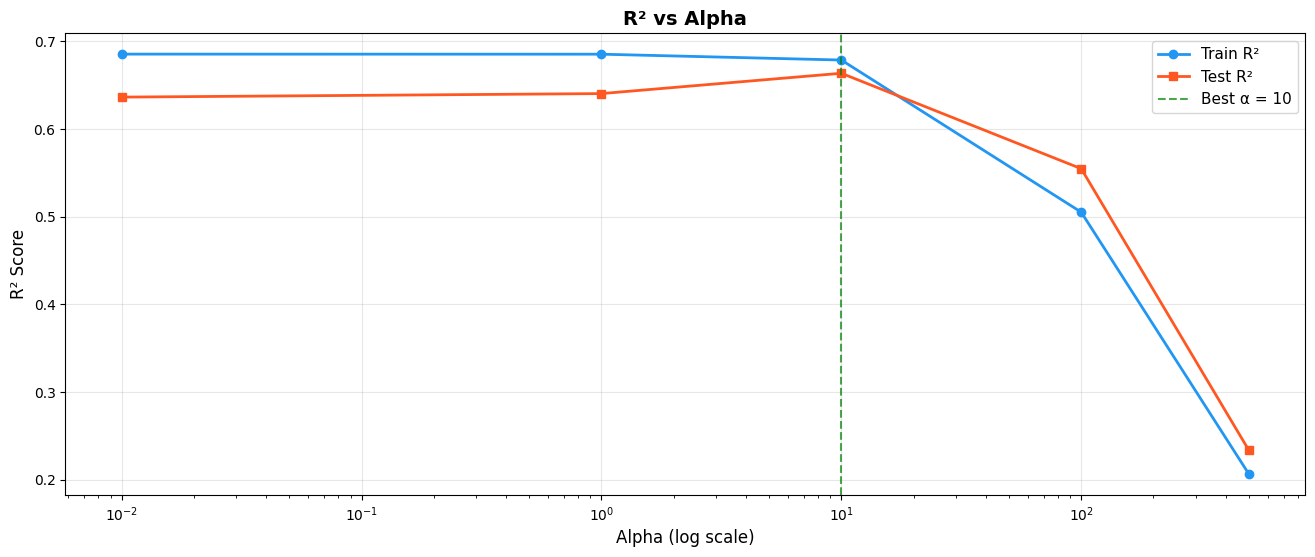

In [18]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, figsize=(16,6))
axes.plot(alphas, r2_train, 'o-', label='Train R²', color='#2196F3', linewidth=2)
axes.plot(alphas, r2_test, 's-', label='Test R²', color='#FF5722', linewidth=2)
axes.axvline(best_alpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {best_alpha}')
axes.set_xscale('log')
axes.set_xlabel('Alpha (log scale)', fontsize=12)
axes.set_ylabel('R² Score', fontsize=12)
axes.set_title('R² vs Alpha', fontsize=14, fontweight='bold')
axes.legend(fontsize=11)
axes.grid(True, alpha=0.3)

In [26]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 1.0, max_iter = 10000)
lasso.fit(X_train_scaled, y_train)
yl_pred = lasso.predict(X_test_scaled)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coff": lasso.coef_
})
print(coef_df)

     Feature      Coff
0  age_years -0.630720
1  km_driven -0.200718
2  engine_cc  1.097302
3  fuel_type  0.000000
4    noise_1  0.000000
5    noise_2  0.000000


In [28]:
seeds = [42,7,123]
for s in seeds:
    Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size = 0.2, random_state = s)
    
    sc = StandardScaler()
    Xtrain_scaled = sc.fit_transform(Xtrain)
    Xtest_scaled = sc.transform(Xtest)

    best_ridge = Ridge(alpha = 10)
    best_ridge.fit(Xtrain_scaled, ytrain)

    ypred = best_ridge.predict(Xtest_scaled)
    r2 = r2_score(ytest, ypred)
    print(f"Random seed set to {s}")
    print(f"R2 Score of this model is {r2}")

Random seed set to 42
R2 Score of this model is 0.6637289233749608
Random seed set to 7
R2 Score of this model is 0.6649135927828621
Random seed set to 123
R2 Score of this model is 0.6025961837001985


In [32]:
# chatgpt code
# 1. IMPORTS & DATA
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

np.random.seed(0)
n = 120

data = {
    'age_years':   np.random.randint(1, 15, n),
    'km_driven':   np.random.randint(5000, 150000, n),
    'engine_cc':   np.random.randint(800, 3500, n),
    'fuel_type':   np.random.randint(0, 2, n),
    'noise_1':     np.random.randn(n),
    'noise_2':     np.random.randn(n),
}

df = pd.DataFrame(data)

df['price_lakhs'] = (
    -0.5  * df['age_years']
    - 0.00003 * df['km_driven']
    + 0.003 * df['engine_cc']
    + 2.0  * df['fuel_type']
    + np.random.randn(n) * 2
)

X = df.drop(columns=['price_lakhs'])
y = df['price_lakhs']

# TASK 1 — BASELINE MODEL

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

train_r2 = r2_score(y_train, lr.predict(X_train_scaled))
test_r2 = r2_score(y_test, lr.predict(X_test_scaled))

print("TASK 1 — BASELINE")
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")

# Train R²: 0.6856
#Test  R²: 0.6365, so I think there is not much difference between both which means a good fit


# TASK 2 — RIDGE TUNING
alphas = [0.01, 1, 10, 100, 500]
results = []

print("\nTASK 2 — RIDGE TUNING")

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    train_r2 = r2_score(y_train, ridge.predict(X_train_scaled))
    test_r2 = r2_score(y_test, ridge.predict(X_test_scaled))

    results.append((alpha, test_r2))

    print(f"Alpha={alpha:<6} Train R²={train_r2:.4f} | Test R²={test_r2:.4f}")

best_alpha = max(results, key=lambda x: x[1])[0]
print(f"\nBest Alpha: {best_alpha}")

# As alpha increases, bias increases (model becomes simpler), variance decreases (less overfitting)



# TASK 3 — LASSO FEATURE SELECTION
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print("\nTASK 3 — LASSO COEFFICIENTS")

for feature, coef in zip(X.columns, lasso.coef_):
    print(f"{feature}: {coef}")

# Features with coefficient = 0 are removed by Lasso, this means they are not contributing to prediction (feature selection).
# here, noise_1 and noise_2 may be zeroed out.


# TASK 4 — VALIDATION STABILITY
print("\nTASK 4 — VALIDATION STABILITY")

seeds = [42, 7, 123]

for s in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=s
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(X_train_scaled, y_train)

    ypred = ridge.predict(X_test_scaled)
    test_r2 = r2_score(y_test, ypred)

    print(f"Seed={s} → Test R²: {test_r2}")

# Small variation across seeds means model is stable (good generalisation)
# Large variation means model is sensitive to data split (unstable)

TASK 1 — BASELINE
Train R²: 0.6856
Test  R²: 0.6365

TASK 2 — RIDGE TUNING
Alpha=0.01   Train R²=0.6856 | Test R²=0.6365
Alpha=1      Train R²=0.6855 | Test R²=0.6405
Alpha=10     Train R²=0.6788 | Test R²=0.6637
Alpha=100    Train R²=0.5052 | Test R²=0.5549
Alpha=500    Train R²=0.2064 | Test R²=0.2335

Best Alpha: 10

TASK 3 — LASSO COEFFICIENTS
age_years: -0.6307199181036397
km_driven: -0.20071790389319968
engine_cc: 1.09730153858452
fuel_type: 0.0
noise_1: 0.0
noise_2: 0.0

TASK 4 — VALIDATION STABILITY
Seed=42 → Test R²: 0.6637289233749608
Seed=7 → Test R²: 0.6649135927828621
Seed=123 → Test R²: 0.6025961837001985
